Let us simulate how different policy could impact the 

In [1]:
#!pip install prophet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from prophet import Prophet


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Introduction

The goal of this notebook is to predict juenile crime using a subset of historical data. 

What will the impact be over the next 5 years, if there was a policy that reduced the use of firearms by 20%.

In [4]:
# load data set
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)


weapon_columns = ["Firearm", "Knife", "Blunt object", "Personal", "Other/unknown Weapon"]
raw_data['Total'] = raw_data[weapon_columns].sum(axis=1)


In [5]:
# Group by Year (national total)
national_data = raw_data.groupby("Year")[["Firearm", "Knife", "Blunt object", "Personal", "Other/unknown Weapon", "Total"]].sum().reset_index()

print(national_data.head())
print(national_data.shape)


   Year  Firearm  Knife  Blunt object  Personal  Other/unknown Weapon  Total
0  1980      816    355            97        86                    77   1431
1  1981      824    311           102        94                    62   1393
2  1982      641    292            89       114                    71   1207
3  1983      565    286            80        88                    71   1090
4  1984      504    209            63        69                    52    897
(41, 7)


Now using Prophet to forecast next 5 years (2021-2025)

In [6]:
df = national_data[["Year", "Firearm"]].rename(columns={"Year": "ds", "Firearm": "y"})
df["ds"] = pd.to_datetime(df["ds"], format="%Y")  # Convert to datetime

# Fit Prophet model
model = Prophet(yearly_seasonality=False)
model.fit(df)

# Create a future dataframe for 2021-2025
future = model.make_future_dataframe(periods=6, freq='Y')

# Make predictions
forecast = model.predict(future)

# Extract 2021-2025 predictions
firearm_forecast = forecast[forecast["ds"].dt.year > df["ds"].dt.year.max()][["ds", "yhat"]]
firearm_forecast["Year"] = firearm_forecast["ds"].dt.year
firearm_forecast = firearm_forecast[["Year", "yhat"]].rename(columns={"yhat": "Predicted_Firearm"})

print(firearm_forecast)

21:12:54 - cmdstanpy - INFO - Chain [1] start processing
21:12:54 - cmdstanpy - INFO - Chain [1] done processing


    Year  Predicted_Firearm
42  2021         628.239721
43  2022         615.926843
44  2023         603.613966
45  2024         591.267354
46  2025         578.954477


The models that we will use to simulate the policy reduction include: linear regression, decision tree, random forest, and gradient boosting

In [7]:
X = np.array(national_data["Year"]).reshape(-1, 1)  # Using year as feature
y = np.array(national_data["Firearm"])  # Firearm incidents as the target variable
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

model_results = {}

for model_name, model in models.items():
    model.fit(X, y)  # Train the model
    y_pred = model.predict(X)  # Predict on the entire data
    mae = mean_absolute_error(y, y_pred)  # Calculate MAE
    r2 = r2_score(y, y_pred)  # Calculate R2 score
    
    model_results[model_name] = {
        'model': model,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"{model_name}: MAE = {mae:.2f}, R2 = {r2:.2f}")


Linear Regression: MAE = 339.56, R2 = 0.10
Decision Tree: MAE = 0.00, R2 = 1.00
Random Forest: MAE = 32.26, R2 = 0.99
Gradient Boosting: MAE = 3.27, R2 = 1.00


In [8]:
# Simulate policy changes: Assume a 20% reduction in firearm incidents
print("\nPolicy Simulation Results:\n")
for name, result in model_results.items():
    model = result["model"]
    
    # Predictions for the original and simulated scenarios (2021-2025)
    pred_original = model.predict(firearm_forecast["Year"].values.reshape(-1, 1))
    pred_policy = pred_original * 0.8  # Simulate a 20% reduction in firearm incidents
    
    # Calculate the average predicted crime count and the change in incidents
    avg_original = np.mean(pred_original)
    avg_policy = np.mean(pred_policy)
    change = avg_policy - avg_original

    print(f"{name} - Avg Predicted Crime (Original): {avg_original:.2f}")
    print(f"{name} - Avg Predicted Crime (With Policy): {avg_policy:.2f}")
    print(f"{name} - Change: {change:.2f} incidents\n")


Policy Simulation Results:

Linear Regression - Avg Predicted Crime (Original): 616.69
Linear Regression - Avg Predicted Crime (With Policy): 493.35
Linear Regression - Change: -123.34 incidents

Decision Tree - Avg Predicted Crime (Original): 1017.00
Decision Tree - Avg Predicted Crime (With Policy): 813.60
Decision Tree - Change: -203.40 incidents

Random Forest - Avg Predicted Crime (Original): 922.55
Random Forest - Avg Predicted Crime (With Policy): 738.04
Random Forest - Change: -184.51 incidents

Gradient Boosting - Avg Predicted Crime (Original): 1013.11
Gradient Boosting - Avg Predicted Crime (With Policy): 810.49
Gradient Boosting - Change: -202.62 incidents



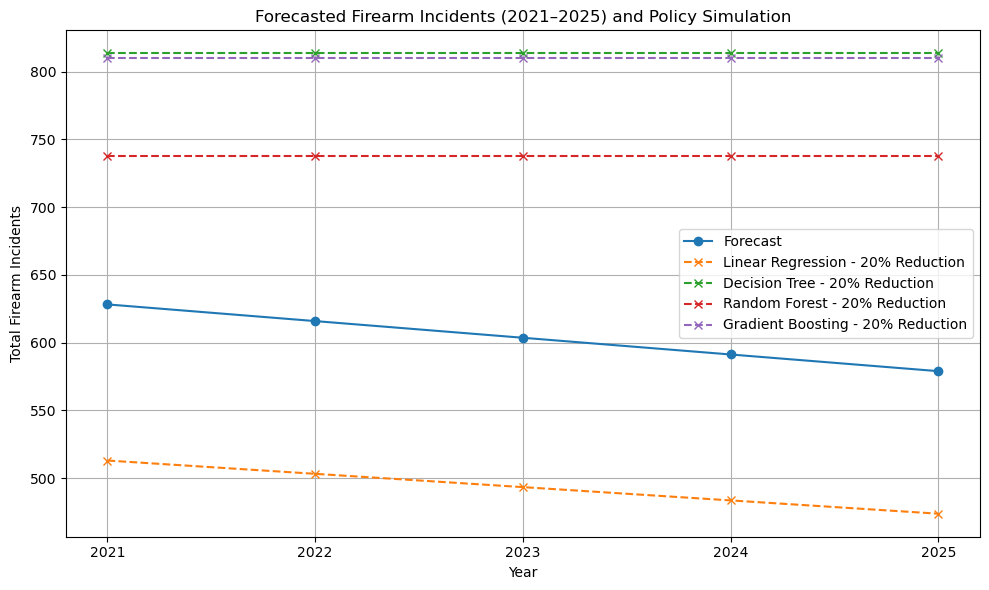

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(firearm_forecast["Year"], firearm_forecast["Predicted_Firearm"], label="Forecast", marker='o')

# Plot the policy simulated results (20% reduction) for each model
for model_name, result in model_results.items():
    model = result["model"]
    
    # Simulate a 20% reduction
    pred_original = model.predict(firearm_forecast["Year"].values.reshape(-1, 1))
    pred_policy = pred_original * 0.8
    
    # Plot the reduction scenario
    plt.plot(firearm_forecast["Year"], pred_policy, label=f"{model_name} - 20% Reduction", linestyle='--', marker='x')

plt.title("Forecasted Firearm Incidents (2021–2025) and Policy Simulation")
plt.xlabel("Year")
plt.ylabel("Total Firearm Incidents")
plt.xticks(firearm_forecast["Year"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()